In [ ]:
# MODELLO 3: senza ricettori e senza saturazione


import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# Impostazione dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

In [15]:
# --- PARAMETRI FISICI ---
# Radionuclide di esempio: Lutezio-177 (177Lu)
T_half = 160.8  # Emivita fisica in ore (~6.7 giorni)
lmbda = np.log(2) / T_half  # Costante di decadimento fisico (h^-1)

# --- PARAMETRI CINETICI ---
# Costanti di velocita per l'interazione radiofarmaco-cellula
kint = 0.01      # Costante di internalizzazione (h^-1)
kout = 1      # Costante di washout fuori dalla cellula (h^-1)

A0 = 100.0       # Attività iniziale iniettata nel terreno di coltura (kBq)

In [16]:
def cellular_kinetic_system(t, y, lmbda, kint, kout):
    """
    Sistema ODE per la cinetica del radiofarmaco in vitro.
    y = [Am, Acell, Adec]
    """
    Am, Acell, Adec = y
    
    # Equazioni differenziali del sistema
    dAm_dt = -lmbda * Am - kint * Am + kout * Acell
    dAcell_dt = kint * Am - (kout + lmbda) * Acell
    dAdec_dt = lmbda * (Am + Acell)
    
    return [dAm_dt, dAcell_dt, dAdec_dt]

# Condizioni iniziali: tutta l'attivita e inizialmente nel terreno Am(0) = A0
y0 = [A0, 0.0, 0.0]

# Intervallo temporale di simulazione (es. 144 ore)
t_span = (0, 144)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Risoluzione del sistema ODE (metodo RK45)
sol = solve_ivp(
    cellular_kinetic_system, 
    t_span, 
    y0, 
    t_eval=t_eval, 
    args=(lmbda, kint, kout),
    method='RK45'
)

# Estrazione dei risultati
t = sol.t
Am, Acell, Adec = sol.y
A_tot = Am + Acell + Adec

# Calcolo dell'Attività Cumulata A_tilde (integrale dell'attività nel tempo)
cumulated_activity_cell = np.trapezoid(Acell, t)  # in kBq*h

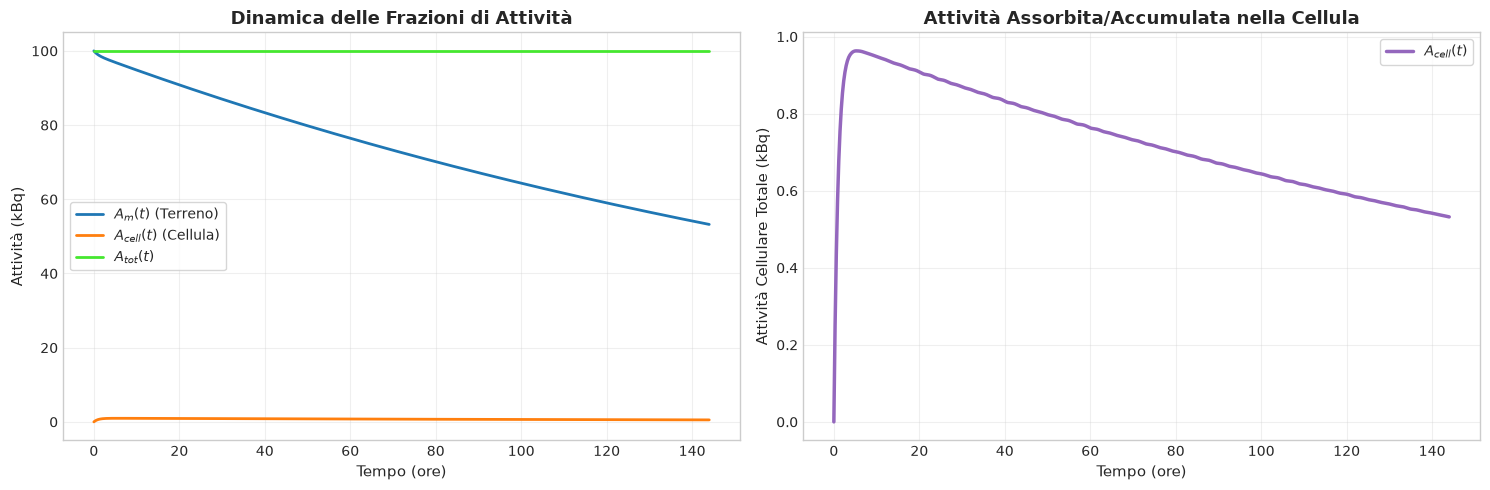

--------------------------------------------------
Attività Cumulata Cellulare Integrata (0-144h): 105.23 kBq·h
--------------------------------------------------


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Cinetica nei tre compartimenti
axes[0].plot(t, Am, label='$A_m(t)$ (Terreno)', color='#1f77b4', linewidth=2)
axes[0].plot(t, Acell, label='$A_{cell}(t)$ (Cellula)', color='#ff7f0e', linewidth=2)
axes[0].plot(t, A_tot, label='$A_{tot}(t)$', color="#45e72f", linewidth=2)
axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività (kBq)', fontsize=11)
axes[0].set_title('Dinamica delle Frazioni di Attività', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Totale Cellulare e Saturazione
axes[1].plot(t, Acell, label='$A_{cell}(t)$', color='#9467bd', linewidth=2.5)
axes[1].set_xlabel('Tempo (ore)', fontsize=11)
axes[1].set_ylabel('Attività Cellulare Totale (kBq)', fontsize=11)
axes[1].set_title('Attività Assorbita/Accumulata nella Cellula', fontsize=13, fontweight='bold')
axes[1].legend(frameon=True)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stampa dell'attività cumulata
print(f"--------------------------------------------------")
print(f"Attività Cumulata Cellulare Integrata (0-{t_span[1]}h): {cumulated_activity_cell:.2f} kBq·h")
print(f"--------------------------------------------------")

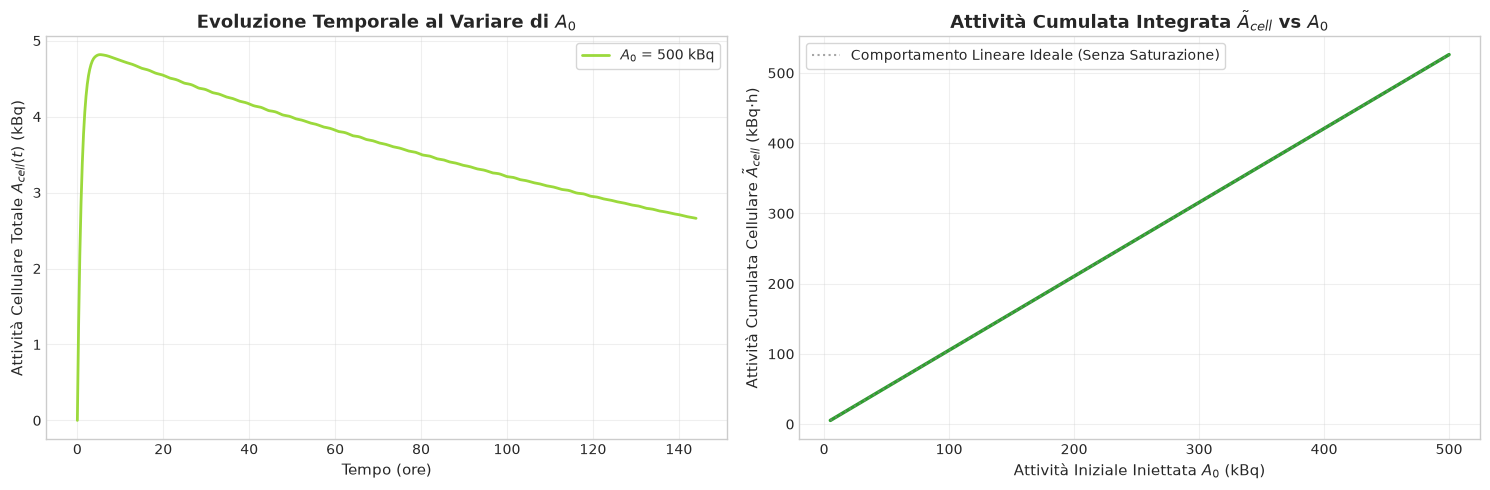

In [18]:
A0_range = np.linspace(5, 500, 60)  # Variazione di A0 da 5 a 500 kBq

cumulated_A_list = []
max_A_cell_list = []

for A0_i in A0_range:
    # Risoluzione ODE per il generico A0_i
    y0_i = [A0_i, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, kint, kout),
        method='RK45'
    )

    Acell = sol_i.y[1]

    # Salviamo il picco massimo e l'attività cumulata integrata (proporzionale alla dose)
    max_A_cell_list.append(np.max(Acell))
    cumulated_A_list.append(np.trapezoid(Acell, sol_i.t))

# --- VISUALIZZAZIONE GRAFICA ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafico 1: Curve temporali A_cell(t) per campioni significativi di A0
A0_samples = [10, 30, 80, 200, 500]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(A0_samples)))

for A0_sample, color in zip(A0_samples, colors):
    sol_sample = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        [A0_sample, 0.0, 0.0], 
        t_eval=t_eval, 
        args=(lmbda, kint, kout),
        method='RK45'
    )

A_cell_sample = sol_sample.y[1]
axes[0].plot(sol_sample.t, A_cell_sample, label=f'$A_0$ = {A0_sample} kBq', color=color, linewidth=2)

axes[0].set_xlabel('Tempo (ore)', fontsize=11)
axes[0].set_ylabel('Attività Cellulare Totale $A_{cell}(t)$ (kBq)', fontsize=11)
axes[0].set_title('Evoluzione Temporale al Variare di $A_0$', fontsize=13, fontweight='bold')
axes[0].legend(frameon=True)
axes[0].grid(True, alpha=0.3)

# Grafico 2: Attività Cumulata vs A0 (Curva di Saturazione)
axes[1].plot(A0_range, cumulated_A_list, color='#2ca02c', linewidth=2.5)
axes[1].set_xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=11)
axes[1].set_ylabel('Attività Cumulata Cellulare $\\tilde{A}_{cell}$ (kBq·h)', fontsize=11)
axes[1].set_title('Attività Cumulata Integrata $\\tilde{A}_{cell}$ vs $A_0$', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Evidenziamo visivamente la deviazione dalla linearità
linear_trend = cumulated_A_list[0] / A0_range[0] * A0_range
axes[1].plot(A0_range, linear_trend, color='gray', linestyle=':', alpha=0.7, label='Comportamento Lineare Ideale (Senza Saturazione)')
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

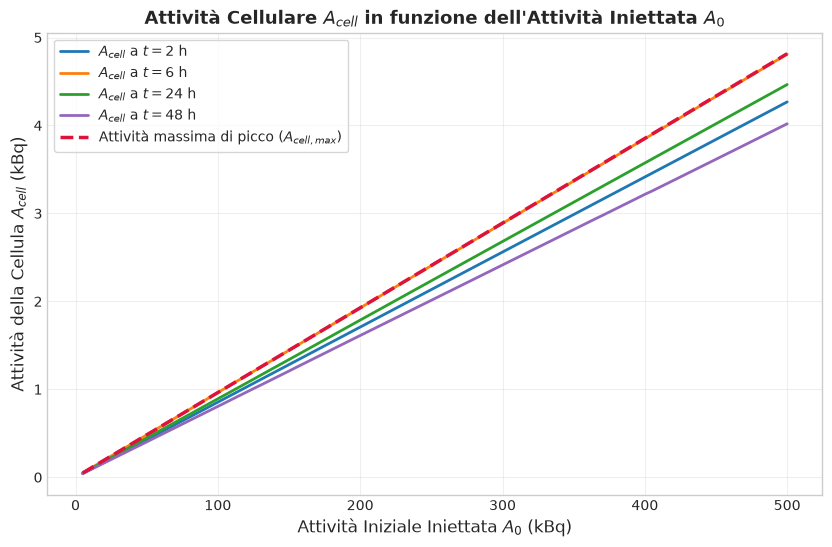

In [19]:
# --- PARAMETRIC SWEEP: A_cell vs A_0 ---
A0_range = np.linspace(5, 500, 100)  # Variazione continua dell'attività iniettata A0

# Tempi specifici a cui estrarre l'attività cellulare (in ore)
time_points = [2, 6, 24, 48]

# Dizionari e liste per raccogliere i dati
A_cell_at_times = {t_val: [] for t_val in time_points}
A_cell_max = []

for A0_i in A0_range:
    y0_i = [A0_i, 0.0, 0.0]
    sol_i = solve_ivp(
        cellular_kinetic_system, 
        t_span, 
        y0_i, 
        t_eval=t_eval, 
        args=(lmbda, kint, kout),
        method='RK45'
    )
    
    A_cell_i = sol_i.y[1] # A_cell(t) = Ab(t) + Aint(t)
    
    # Estraggo A_cell ai tempi prefissati
    for t_val in time_points:
        idx = np.argmin(np.abs(sol_i.t - t_val))  # Indice dell'istante t più vicino
        A_cell_at_times[t_val].append(A_cell_i[idx])
        
    # Estraggo il picco massimo assoluto di A_cell
    A_cell_max.append(np.max(A_cell_i))

# --- VISUALIZZAZIONE GRAFICA ---
plt.figure(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

# Curve di A_cell(A0) ai vari tempi
for t_val, color in zip(time_points, colors):
    plt.plot(A0_range, A_cell_at_times[t_val], 
             label=f'$A_{{cell}}$ a $t = {t_val}$ h', 
             color=color, linewidth=2)

# Curva del picco massimo A_cell_max(A0)
plt.plot(A0_range, A_cell_max, 
         label='Attività massima di picco ($A_{cell, max}$)', 
         color='crimson', linestyle='--', linewidth=2.5)

# Formattazione grafico
plt.xlabel('Attività Iniziale Iniettata $A_0$ (kBq)', fontsize=12)
plt.ylabel('Attività della Cellula $A_{cell}$ (kBq)', fontsize=12)
plt.title('Attività Cellulare $A_{cell}$ in funzione dell\'Attività Iniettata $A_0$', fontsize=13, fontweight='bold')
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

plt.show()

          RISULTATI DEL FIT SUI DATI REAL         
kint (Associazione)   : 0.000411 ± 0.000154 h^-1
kout    (Dissociazione) : 0.265519 ± 0.107471 h^-1
--------------------------------------------------
Chi-quadro Totale (Chi2) : 13.7182
Gradi di libertà (dof)   : 7
Chi-quadro Ridotto       : 1.9597


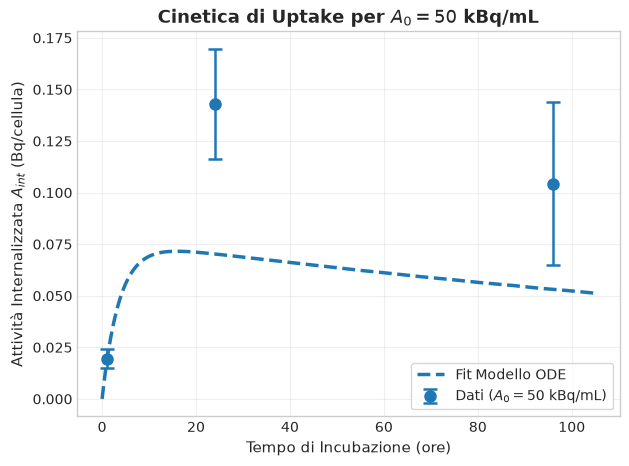

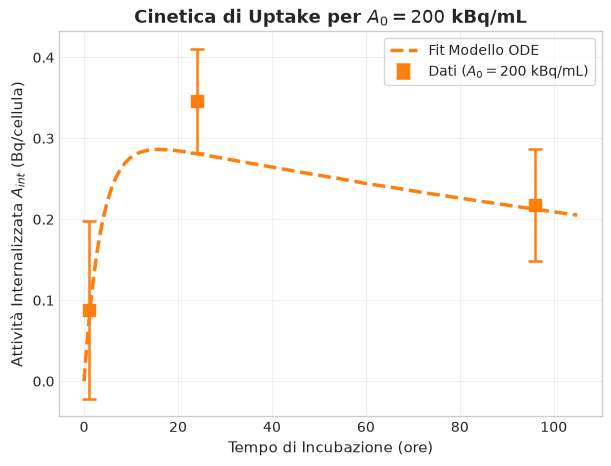

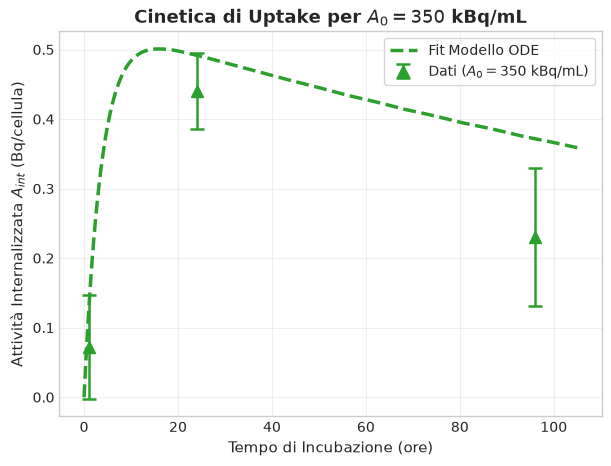

In [23]:
# =============================================================================
# 1. STRUTTURAZIONE DATI SPERIMENTALI
# =============================================================================
# Tempi di incubazione (ore)
t_exp = np.array([1.0, 24.0, 96.0])

# Attività iniettate A0 (kBq/mL)
A0_exp = np.array([50.0, 200.0, 350.0])

# Rumore di fondo misurato a A0 = 0 (Bq/cellula)
bg = np.array([0.004199309, 0.003368672, 0.000942459])

# Matrice Attività Cellulare Misurata A_int_raw (Bq/cellula)
# Righe: A0 (50, 200, 350 kBq/mL) | Colonne: Tempi (1h, 24h, 96h)
A_int_raw = np.array([
    [0.023594163, 0.146368766, 0.105341900],  # A0 = 50
    [0.092211399, 0.349493079, 0.218233662],  # A0 = 200
    [0.076153440, 0.443769956, 0.231148121]   # A0 = 350
])

# Matrice delle Incertezze Sperimentali (err)
err_matrix = np.array([
    [0.004641692, 0.026652162, 0.039304734],  # A0 = 50
    [0.109901502, 0.064321945, 0.068945026],  # A0 = 200
    [0.074465535, 0.055049521, 0.099395703]   # A0 = 350
])

# Sottrazione del fondo per ottenere l'attività netta internalizzata
A_int_net = np.maximum(A_int_raw - bg, 1e-6)

# Parametro fisico: Emivita radionuclide in ore
# IMPO: Modifica T_half con l'emivita esatta del radionuclide usato nel tuo esperimento!
T_half = 7.4 * 24
lmbda = np.log(2) / T_half

# =============================================================================
# 2. MODELLO ODE E RESIDUI PESATI (CHI-QUADRO)
# =============================================================================
def model_predictions(params, t_points, A0_values):
    """Risolve il sistema ODE per le varie concentrazioni A0."""
    kint, kout = params

    predictions = []
    t_span = (0, max(t_points))
    
    for A0 in A0_values:
        sol = solve_ivp(cellular_kinetic_system, t_span, [A0, 0.0, 0.0], t_eval=t_points, args=(lmbda, kint, kout), method='RK45')
        predictions.append(sol.y[1])  # Estraiamo solo il compartimento cellula
        
    return np.array(predictions)

def weighted_residuals(params, t_points, A0_values, data_matrix, weights_matrix):
    """Calcola i residui pesati con l'incertezza sperimentale: (Pred - Dati) / σ"""
    preds = model_predictions(params, t_points, A0_values)
    return ((preds - data_matrix) / weights_matrix).flatten()

# =============================================================================
# 3. CONDIZIONI INIZIALI, FIT E CALCOLO ERRORI
# =============================================================================
p0 = [0.1, 1]

# Limiti sui parametri (Bounds)
lower_bounds = [1e-4, 0.0]
upper_bounds = [5., 1.0]

# Fit
res_fit = least_squares(
    weighted_residuals, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(t_exp, A0_exp, A_int_net, err_matrix),
    method='trf'
)

# Estrazione dei 5 parametri ottimizzati
kint_f, kout_f = res_fit.x

# -----------------------------------------------------------------------------
# CALCOLO STIMA DEGLI ERRORI SUI PARAMETRI
# -----------------------------------------------------------------------------
N = A_int_net.size      # Numero totale di punti sperimentali (3 tempi x 3 conc = 9)
p = len(res_fit.x)      # Numero di parametri stimati (5)
dof = N - p             # Gradi di libertà (9 - 5 = 4)

# Somma dei quadrati dei residui pesati (Chi-quadro)
chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

# Calcolo della matrice di covarianza tramite la Jacobiana J
J = res_fit.jac
try:
    # Usiamo np.linalg.pinv (pseudo-inversa) per evitare errori se J^T J è quasi-singolare
    cov = np.linalg.pinv(J.T @ J)
    
    # Gli errori standard sono la radice della diagonale scalati con il Chi2 ridotto
    param_errors = np.sqrt(np.diagonal(cov) * chi2_red)
except Exception as e:
    param_errors = np.full(p, np.nan)
    print(f"Attenzione: Impossibile calcolare la covarianza ({e})")

# Unpacking degli errori
kint_err, kout_err = param_errors

# -----------------------------------------------------------------------------
# STAMPA RISULTATI CON INCERTEZZE
# -----------------------------------------------------------------------------
t_smooth = np.linspace(0, 105, 300)
preds_smooth = model_predictions(res_fit.x, t_smooth, A0_exp)

print("==================================================")
print("          RISULTATI DEL FIT SUI DATI REAL         ")
print("==================================================")
print(f"kint (Associazione)   : {kint_f:.6f} ± {kint_err:.6f} h^-1")
print(f"kout    (Dissociazione) : {kout_f:.6f} ± {kout_err:.6f} h^-1")
print("--------------------------------------------------")
print(f"Chi-quadro Totale (Chi2) : {chi2:.4f}")
print(f"Gradi di libertà (dof)   : {dof}")
print(f"Chi-quadro Ridotto       : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# GRAFICI
# =============================================================================

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blu, Arancione, Verde
markers = ['o', 's', '^']                   # Cerchio, Quadrato, Triangolo

for i, A0 in enumerate(A0_exp):
    plt.figure(figsize=(7, 5))
    
    # Dati sperimentali
    plt.errorbar(t_exp, A_int_net[i], yerr=err_matrix[i], 
                 fmt=markers[i], color=colors[i], ecolor=colors[i], elinewidth=1.8,
                 capsize=5, capthick=1.8, markersize=8, zorder=5,
                 label=f'Dati ($A_0 = {A0:.0f}$ kBq/mL)')
    
    # Curva di fit ODE
    plt.plot(t_smooth, preds_smooth[i], color=colors[i], linestyle='--', linewidth=2.5, 
             label='Fit Modello ODE')
    
    plt.title(f'Cinetica di Uptake per $A_0 = {A0:.0f}$ kBq/mL', fontsize=13, fontweight='bold')
    plt.xlabel('Tempo di Incubazione (ore)', fontsize=11)
    plt.ylabel('Attività Internalizzata $A_{int}$ (Bq/cellula)', fontsize=11)
    plt.legend(frameon=True, fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Rimuovi il commento sottostante se desideri salvare i grafici come immagini PNG:
    # plt.savefig(f'uptake_fit_A0_{int(A0)}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1177557/850384976.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='Banda $\pm 2\sigma$')
/tmp/ipykernel_1177557/850384976.py:22: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Residui Pesati (Unità di $\sigma$)', fontsize=11)


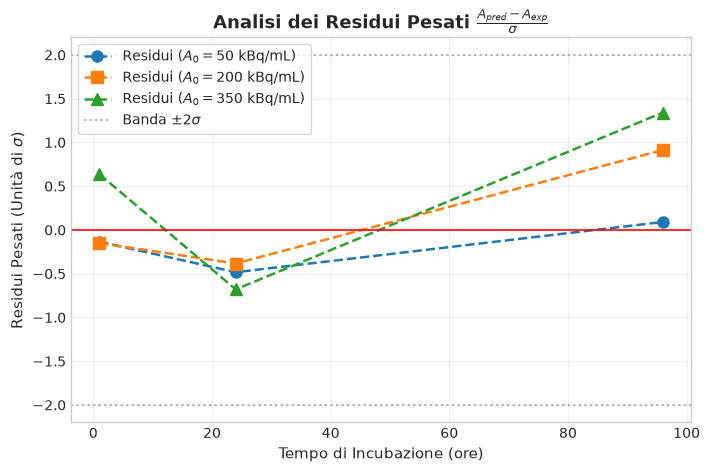

In [75]:
# =============================================================================
# ANALISI DEI RESIDUI PESATI
# =============================================================================

# Calcolo delle predizioni e della matrice dei residui pesati (Pred - Dati) / sigma
preds_net = model_predictions(res_fit.x, t_exp, A0_exp)
residuals_matrix = (preds_net - A_int_net) / err_matrix

plt.figure(figsize=(8, 5))
for i, A0 in enumerate(A0_exp):
    plt.plot(t_exp, residuals_matrix[i], marker=markers[i], color=colors[i], 
             linestyle='--', linewidth=1.8, markersize=8,
             label=f'Residui ($A_0 = {A0:.0f}$ kBq/mL)')

# Linea di riferimento a 0 e bande a +- 2 sigma
plt.axhline(0, color='red', linestyle='-', linewidth=1.5, alpha=0.8)
plt.axhline(2, color='gray', linestyle=':', alpha=0.6, label='Banda $\pm 2\sigma$')
plt.axhline(-2, color='gray', linestyle=':', alpha=0.6)

plt.title('Analisi dei Residui Pesati $\\frac{A_{pred} - A_{exp}}{\\sigma}$', fontsize=13, fontweight='bold')
plt.xlabel('Tempo di Incubazione (ore)', fontsize=11)
plt.ylabel('Residui Pesati (Unità di $\sigma$)', fontsize=11)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

         MATRICE DI CORRELAZIONE PARAMETRI        
Param           kint      kout     B_max
----------------------------------------
kint           1.000     0.713     0.073
kout           0.713     1.000     0.607
B_max          0.073     0.607     1.000


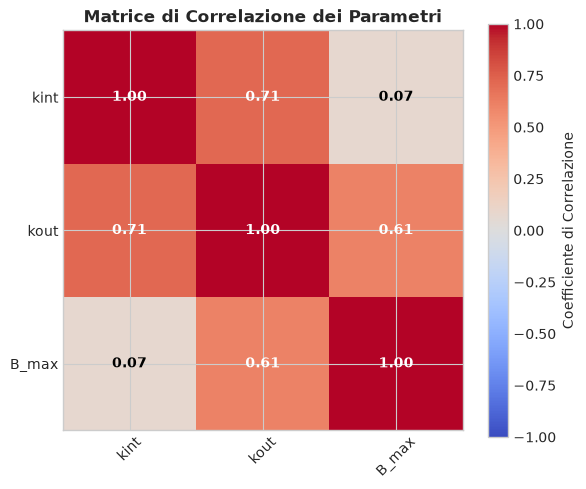

In [ ]:
# Derivazione della matrice di correlazione R_ij = Cov_ij / (sigma_i * sigma_j)
stds = np.sqrt(np.diagonal(cov))
corr_matrix = cov / np.outer(stds, stds)

param_names = ['kint', 'kout']

# Stampa in console
print("==================================================")
print("         MATRICE DI CORRELAZIONE PARAMETRI        ")
print("==================================================")
header = f"{'Param':<10}" + "".join([f"{name:>10}" for name in param_names])
print(header)
print("-" * len(header))
for i, name in enumerate(param_names):
    row = f"{name:<10}" + "".join([f"{corr_matrix[i, j]:>10.3f}" for j in range(len(param_names))])
    print(row)
print("==================================================")

# Visualizzazione via Heatmap
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Coefficiente di Correlazione')
plt.xticks(range(len(param_names)), param_names, rotation=45)
plt.yticks(range(len(param_names)), param_names)
plt.title('Matrice di Correlazione dei Parametri', fontsize=12, fontweight='bold')

for i in range(len(param_names)):
    for j in range(len(param_names)):
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr_matrix[i, j]) > 0.6 else 'black', fontweight='bold')

plt.tight_layout()
plt.show()

In [77]:
# =============================================================================
# MONTE CARLO BOOTSTRAPPING (200 SIMULAZIONI)
# =============================================================================
n_iterations = 200
boot_params = []

np.random.seed(42)  # Riproducibilità

for _ in range(n_iterations):
    # Generazione dati sintetici distribuiti normalmente attorno ai dati medi
    synthetic_data = np.random.normal(loc=A_int_net, scale=err_matrix)
    synthetic_data = np.maximum(synthetic_data, 1e-6)
    
    # Refit
    res_boot = least_squares(
        weighted_residuals, p0, bounds=(lower_bounds, upper_bounds),
        args=(t_exp, A0_exp, synthetic_data, err_matrix), method='trf'
    )
    boot_params.append(res_boot.x)

boot_params = np.array(boot_params)

print("==================================================")
print("      ANALISI BOOTSTRAP MONTE CARLO (200 iter)    ")
print("==================================================")
for i, name in enumerate(param_names):
    mean_val = np.mean(boot_params[:, i])
    std_val = np.std(boot_params[:, i])
    ci_lower = np.percentile(boot_params[:, i], 2.5)
    ci_upper = np.percentile(boot_params[:, i], 97.5)
    print(f"{name:<10}: Media = {mean_val:.6f} | Std = {std_val:.6f} | IC 95% = [{ci_lower:.6f}, {ci_upper:.6f}]")
print("==================================================")

      ANALISI BOOTSTRAP MONTE CARLO (200 iter)    
kint      : Media = 0.000431 | Std = 0.000091 | IC 95% = [0.000275, 0.000616]
kout      : Media = 0.118410 | Std = 0.048973 | IC 95% = [0.045842, 0.228707]
B_max     : Media = 0.705094 | Std = 0.344474 | IC 95% = [0.368488, 1.695394]


In [78]:
# =============================================================================
# DOSIMETRIA
# =============================================================================
from scipy.integrate import trapezoid

# Griglia temporale estesa per integrare fino a decadimento radiativo completo (es. 500 ore)
t_dosimetry = np.linspace(0, 500, 1000)
preds_dosimetry = model_predictions(res_fit.x, t_dosimetry, A0_exp)

# Efficienza di Internalizzazione
eta = kint_f / (kout_f + kint_f) * 100

print("==================================================")
print("        METRICHE CINETICHE E DOSIMETRICHE         ")
print("==================================================")
print(f"Efficienza di Internalizzazione (eta) : {eta:.2f}%")
print("--------------------------------------------------")

for i, A0 in enumerate(A0_exp):
    curve = preds_dosimetry[i]
    # Attività cumulata (AUC) in Bq*h/cellula
    auc = trapezoid(curve, t_dosimetry)
    
    # Peak Uptake (t_max) e Valore massimo (A_max)
    idx_max = np.argmax(curve)
    t_max = t_dosimetry[idx_max]
    a_max = curve[idx_max]
    
    print(f"A0 = {A0:.0f} kBq/mL:")
    print(f"  - AUC (Attività Cumulata) : {auc:.4f} Bq·h/cellula")
    print(f"  - Peak Uptake (t_max)     : {t_max:.2f} ore (Max A_int: {a_max:.4f} Bq/cellula)")
print("==================================================")

        METRICHE CINETICHE E DOSIMETRICHE         
Efficienza di Internalizzazione (eta) : 0.38%
--------------------------------------------------
A0 = 50 kBq/mL:
  - AUC (Attività Cumulata) : 34.7666 Bq·h/cellula
  - Peak Uptake (t_max)     : 28.03 ore (Max A_int: 0.1306 Bq/cellula)
A0 = 200 kBq/mL:
  - AUC (Attività Cumulata) : 99.3966 Bq·h/cellula
  - Peak Uptake (t_max)     : 21.02 ore (Max A_int: 0.3219 Bq/cellula)
A0 = 350 kBq/mL:
  - AUC (Attività Cumulata) : 136.8606 Bq·h/cellula
  - Peak Uptake (t_max)     : 16.52 ore (Max A_int: 0.4054 Bq/cellula)
